In [6]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

In [7]:
def load_all_results():
    files = {
        "Prompt-Only": "gemini/results_prompt_gemini.json",
        "RAG": "gemini/results_rag_gemini.json",
        "Context-Filtered": "gemini/results_context_gemini.json"
    }
    
    all_data = []
    for system_name, filename in files.items():
        try:
            with open(filename, 'r') as f:
                data = json.load(f)
                # Ensure the system label is consistent for the paper
                for entry in data:
                    entry['system'] = system_name
                all_data.extend(data)
        except FileNotFoundError:
            print(f"Warning: {filename} not found. Skipping...")
            
    return pd.DataFrame(all_data)

In [8]:
df = load_all_results()

In [9]:
summary = df.groupby('system').agg({
    'EM': lambda x: (x.mean() * 100).round(2),
    'latency': 'mean',
    'prompt_tokens_used': 'mean'
}).reset_index()

summary.columns = ['System', 'Avg. EM (%)', 'Avg. Latency (s)', 'Avg. Tokens']
print("TABLE 1: SUMMARY PERFORMANCE")
print(summary.to_string(index=False))

TABLE 1: SUMMARY PERFORMANCE
          System  Avg. EM (%)  Avg. Latency (s)  Avg. Tokens
Context-Filtered         80.0          4.873908     45264.56
     Prompt-Only         80.0          5.675201     79040.11
             RAG         67.0          3.016435      2665.14


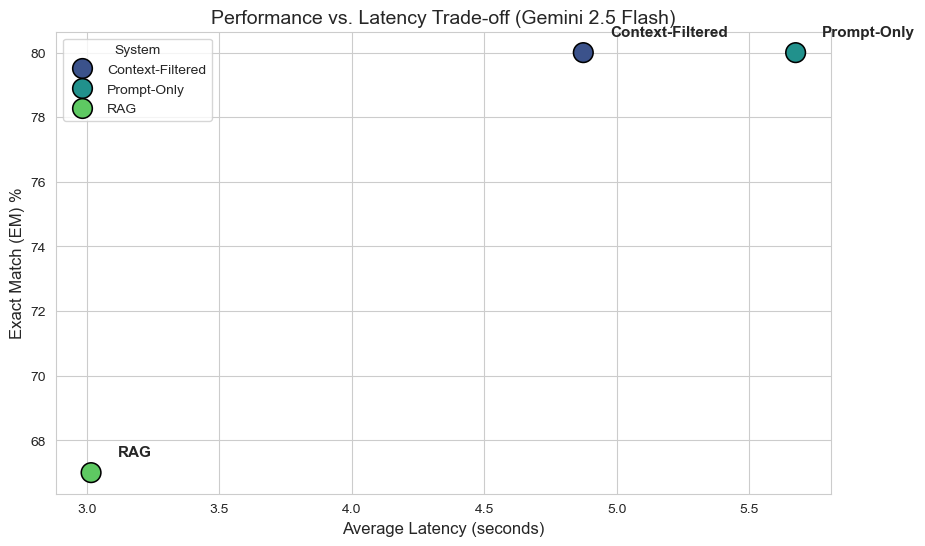

In [10]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create the scatter plot
scatter = sns.scatterplot(
    data=summary, 
    x='Avg. Latency (s)', 
    y='Avg. EM (%)', 
    hue='System', 
    s=200, 
    palette='viridis',
    edgecolor='black'
)

# Label the points
for i in range(summary.shape[0]):
    plt.text(
        summary['Avg. Latency (s)'][i] + 0.1, 
        summary['Avg. EM (%)'][i] + 0.5, 
        summary['System'][i], 
        fontsize=11, fontweight='bold'
    )

plt.title('Performance vs. Latency Trade-off (Gemini 2.5 Flash)', fontsize=14)
plt.ylabel('Exact Match (EM) %', fontsize=12)
plt.xlabel('Average Latency (seconds)', fontsize=12)
plt.savefig('latency_accuracy_tradeoff_gemini.png', dpi=300)

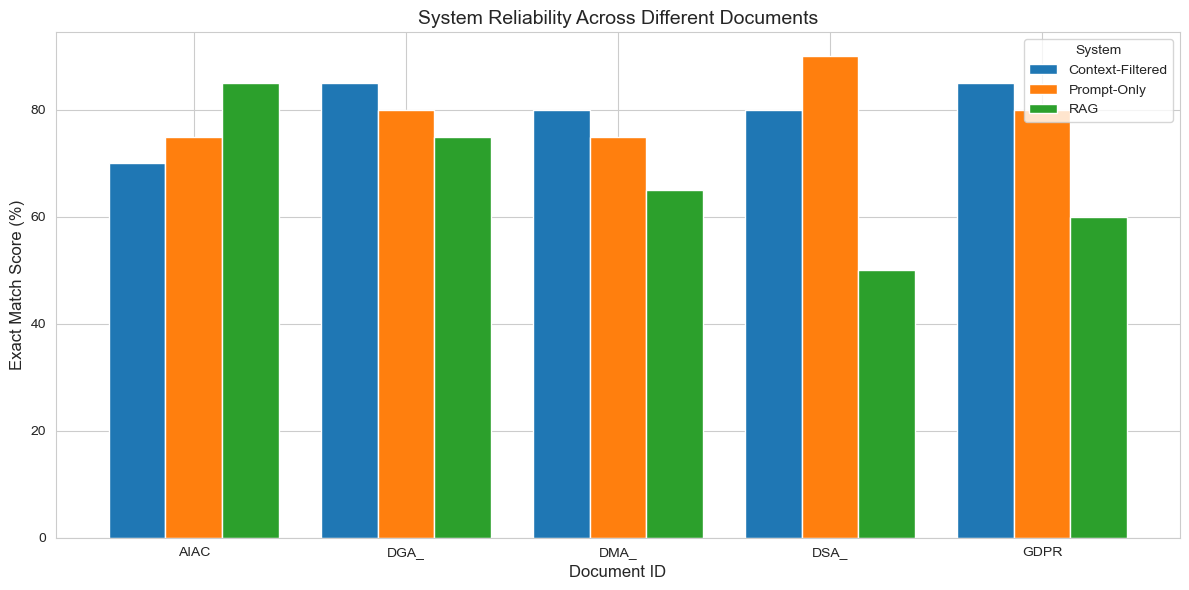

In [13]:
if 'qa_id' in df.columns:
    plt.figure(figsize=(12, 6))
    doc_comparison = df.groupby([df['qa_id'].str[:4], 'system'])['EM'].mean().unstack() * 100
    doc_comparison.plot(kind='bar', width=0.8, ax=plt.gca())
    
    plt.title('System Reliability Across Different Documents', fontsize=14)
    plt.ylabel('Exact Match Score (%)', fontsize=12)
    plt.xlabel('Document ID', fontsize=12)
    plt.legend(title='System', loc='upper right')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig('document_robustness_gemini.png', dpi=300)